# Visualisasi Hasil Klasifikasi dan Clustering

Notebook ini membaca output TF-IDF Logistic Regression, IndoBERT, dan burst review clustering, lalu membuat grafik eksploratif dengan seaborn.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## Load report files

In [2]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "pyproject.toml").exists() and (candidate / "reports").exists():
            return candidate
    raise FileNotFoundError("Project root with pyproject.toml and reports/ not found.")


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def load_confusion_matrix(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, index_col=0)


def find_indobert_report_dir(reports_dir: Path) -> Path:
    for name in ["indobert", "indobert-smoke"]:
        candidate = reports_dir / name
        if (candidate / "metrics.json").exists() and (candidate / "confusion_matrix.csv").exists():
            return candidate
    raise FileNotFoundError("No IndoBERT report found. Expected reports/indobert or reports/indobert-smoke.")


ROOT = find_project_root()
REPORTS_DIR = ROOT / "reports"
TFIDF_DIR = REPORTS_DIR / "tfidf_baseline"
INDOBERT_DIR = find_indobert_report_dir(REPORTS_DIR)
CLUSTER_DIR = REPORTS_DIR / "burst_clustering"

tfidf_metrics = load_json(TFIDF_DIR / "metrics.json")
indobert_metrics = load_json(INDOBERT_DIR / "metrics.json")
cluster_summary = load_json(CLUSTER_DIR / "summary.json")

tfidf_cm = load_confusion_matrix(TFIDF_DIR / "confusion_matrix.csv")
indobert_cm = load_confusion_matrix(INDOBERT_DIR / "confusion_matrix.csv")
cluster_df = pd.read_csv(CLUSTER_DIR / "entity_burst_clusters.csv")

required_cluster_columns = {
    "item_id",
    "review_count",
    "span_days",
    "max_reviews_per_window",
    "burst_risk_score",
    "dbscan_cluster",
    "is_dbscan_anomaly",
    "kmeans_cluster_name",
}
missing_columns = required_cluster_columns - set(cluster_df.columns)
if missing_columns:
    raise ValueError(f"Missing clustering columns: {sorted(missing_columns)}")

print(f"Project root: {ROOT}")
print(f"IndoBERT report: {INDOBERT_DIR.relative_to(ROOT)}")
print(f"Clustering entities: {len(cluster_df):,}")
print(f"Clustering time range: {cluster_summary.get('ctime_min')} to {cluster_summary.get('ctime_max')}")

Project root: C:\Users\lfaja\OneDrive\Documents\Researches\2026_FakeReviewDetection
IndoBERT report: reports\indobert-smoke
Clustering entities: 144
Clustering time range: 2019-04-04T10:03:56 to 2020-05-30T04:23:55


## Classification metrics

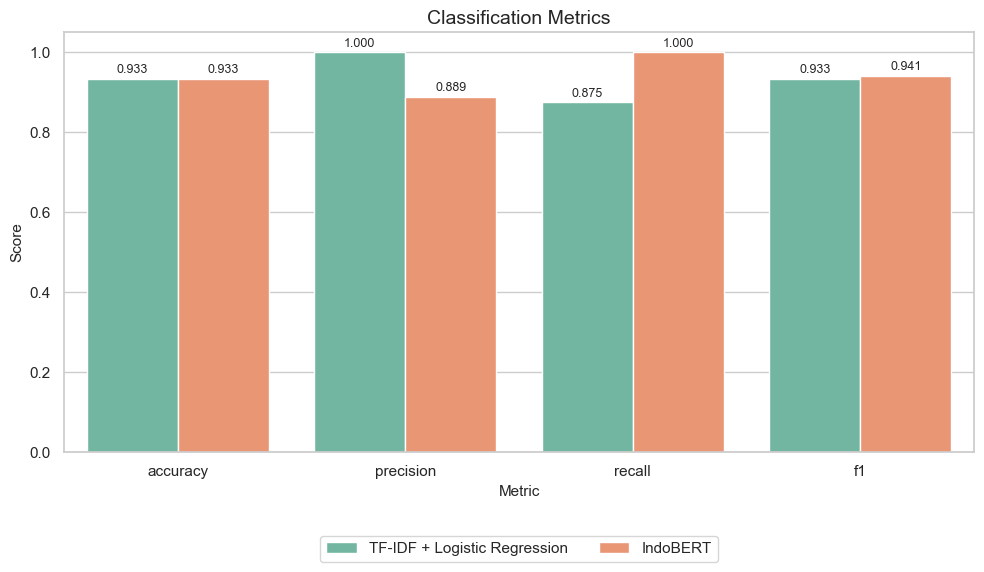

model,IndoBERT,TF-IDF + Logistic Regression
metric,,
accuracy,0.9333,0.9333
f1,0.9412,0.9333
precision,0.8889,1.0000
recall,1.0000,0.8750


In [3]:
metric_names = ["accuracy", "precision", "recall", "f1"]
metrics_df = pd.DataFrame(
    [
        {"model": "TF-IDF + Logistic Regression", "metric": metric, "score": tfidf_metrics[metric]}
        for metric in metric_names
    ]
    + [
        {"model": "IndoBERT", "metric": metric, "score": indobert_metrics[metric]}
        for metric in metric_names
    ]
)

ax = sns.barplot(data=metrics_df, x="metric", y="score", hue="model", palette="Set2")
ax.set_title("Classification Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.28), ncol=2, title=None)
plt.tight_layout()
plt.show()

metrics_df.pivot(index="metric", columns="model", values="score").round(4)

## Confusion matrices

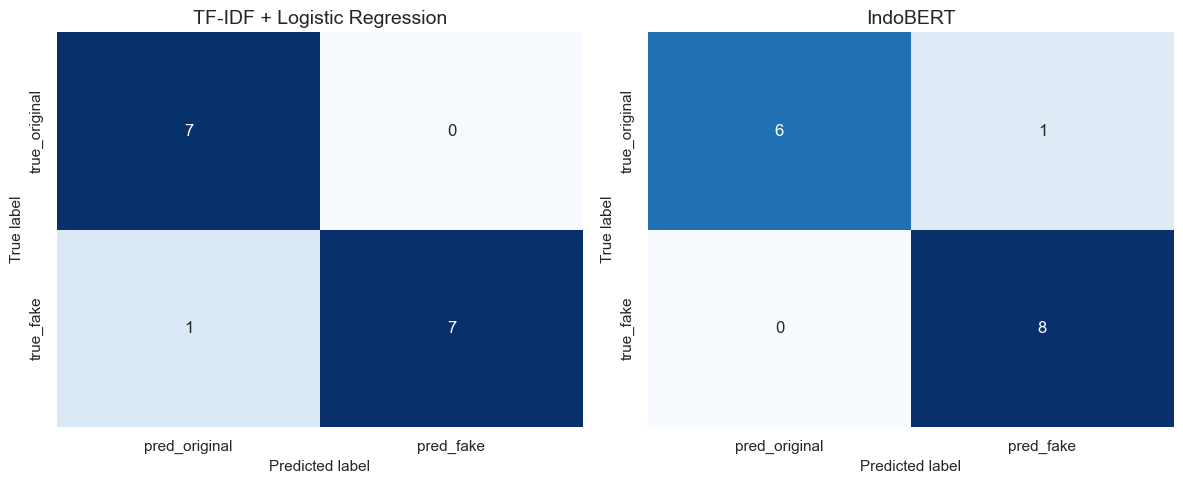

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title in [
    (axes[0], tfidf_cm, "TF-IDF + Logistic Regression"),
    (axes[1], indobert_cm, "IndoBERT"),
]:
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

## DBSCAN cluster distribution

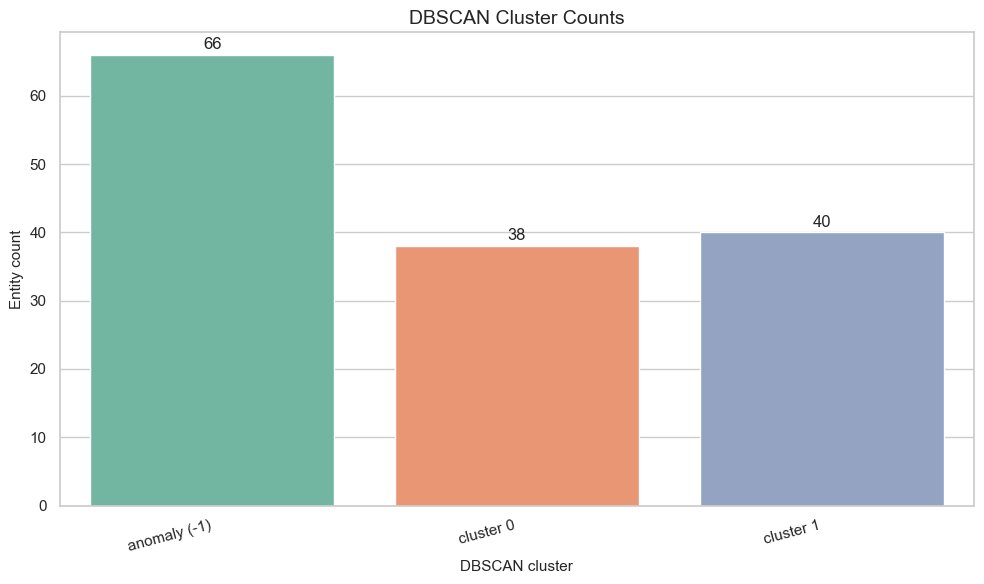

,dbscan_cluster,entity_count,cluster_label
0,-1,66,anomaly (-1)
2,0,38,cluster 0
1,1,40,cluster 1


In [5]:
dbscan_counts = (
    cluster_df["dbscan_cluster"]
    .value_counts()
    .rename_axis("dbscan_cluster")
    .reset_index(name="entity_count")
    .sort_values("dbscan_cluster")
)
dbscan_counts["cluster_label"] = dbscan_counts["dbscan_cluster"].map(lambda value: "anomaly (-1)" if value == -1 else f"cluster {value}")

ax = sns.barplot(data=dbscan_counts, x="cluster_label", y="entity_count", palette="Set2", hue="cluster_label", legend=False)
ax.set_title("DBSCAN Cluster Counts")
ax.set_xlabel("DBSCAN cluster")
ax.set_ylabel("Entity count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

dbscan_counts

## KMeans 3-cluster distribution

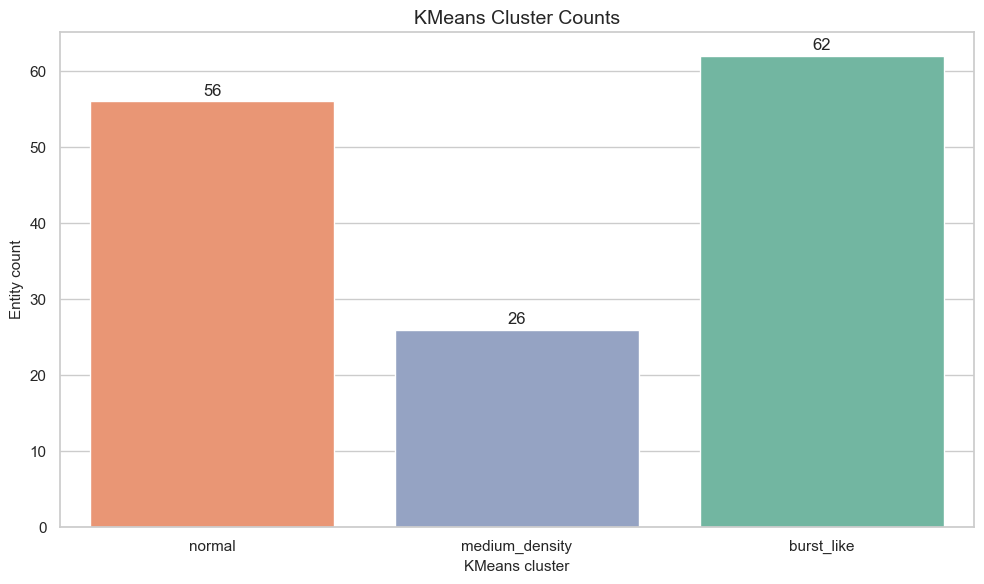

,kmeans_cluster_name,entity_count
0,burst_like,62
1,normal,56
2,medium_density,26


In [6]:
cluster_order = ["normal", "medium_density", "burst_like"]
kmeans_counts = (
    cluster_df["kmeans_cluster_name"]
    .value_counts()
    .rename_axis("kmeans_cluster_name")
    .reset_index(name="entity_count")
)

ax = sns.barplot(
    data=kmeans_counts,
    x="kmeans_cluster_name",
    y="entity_count",
    order=[name for name in cluster_order if name in set(kmeans_counts["kmeans_cluster_name"])],
    palette="Set2",
    hue="kmeans_cluster_name",
    legend=False,
)
ax.set_title("KMeans Cluster Counts")
ax.set_xlabel("KMeans cluster")
ax.set_ylabel("Entity count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)
plt.tight_layout()
plt.show()

kmeans_counts

## Burst risk by KMeans cluster

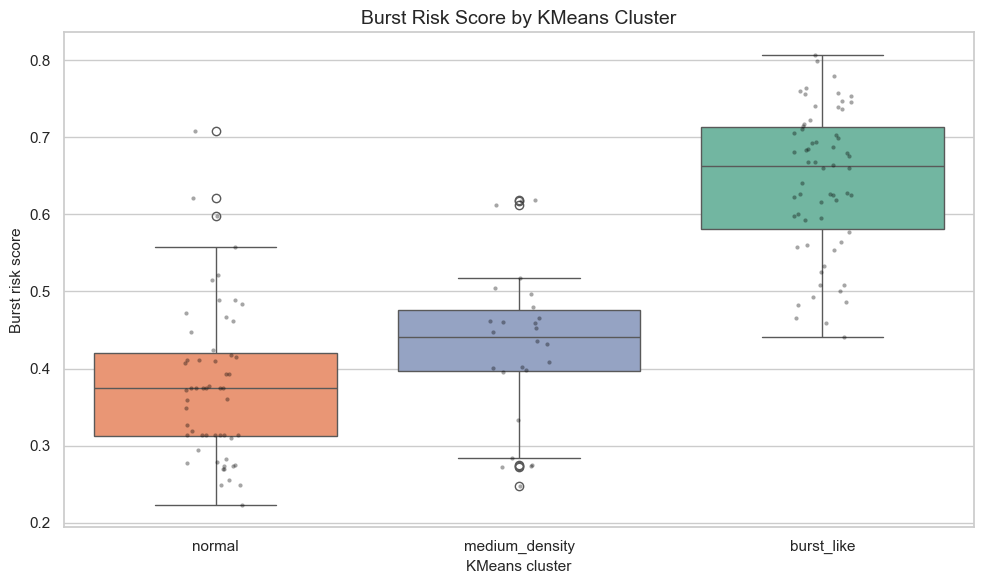

In [7]:
available_order = [name for name in cluster_order if name in set(cluster_df["kmeans_cluster_name"])]
ax = sns.boxplot(
    data=cluster_df,
    x="kmeans_cluster_name",
    y="burst_risk_score",
    order=available_order,
    palette="Set2",
    hue="kmeans_cluster_name",
    legend=False,
)
sns.stripplot(
    data=cluster_df,
    x="kmeans_cluster_name",
    y="burst_risk_score",
    order=available_order,
    color="black",
    alpha=0.35,
    size=3,
    ax=ax,
)
ax.set_title("Burst Risk Score by KMeans Cluster")
ax.set_xlabel("KMeans cluster")
ax.set_ylabel("Burst risk score")
plt.tight_layout()
plt.show()

## Burst density scatterplot

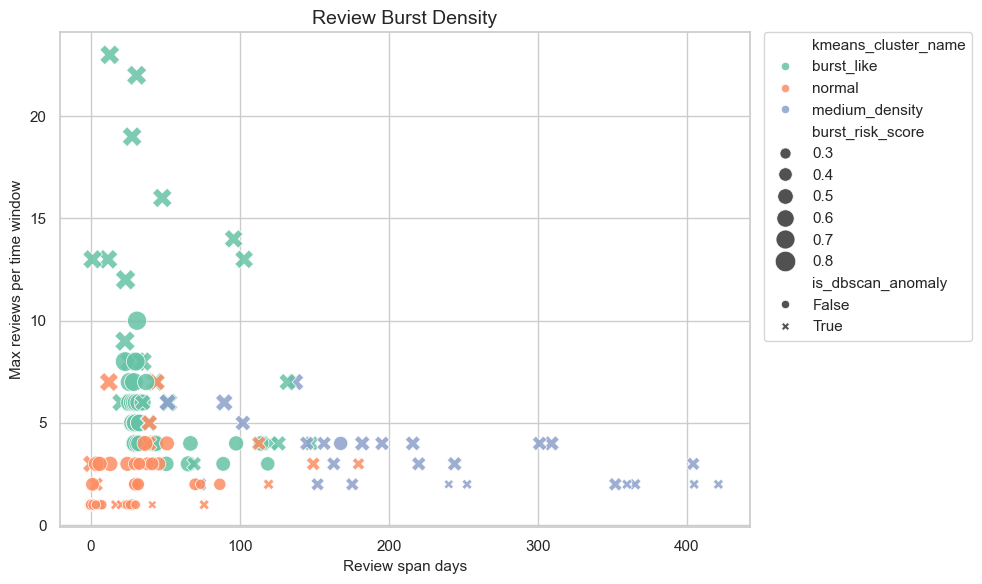

In [8]:
ax = sns.scatterplot(
    data=cluster_df,
    x="span_days",
    y="max_reviews_per_window",
    hue="kmeans_cluster_name",
    style="is_dbscan_anomaly",
    size="burst_risk_score",
    sizes=(40, 220),
    palette="Set2",
    alpha=0.85,
)
ax.set_title("Review Burst Density")
ax.set_xlabel("Review span days")
ax.set_ylabel("Max reviews per time window")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## Top burst candidates

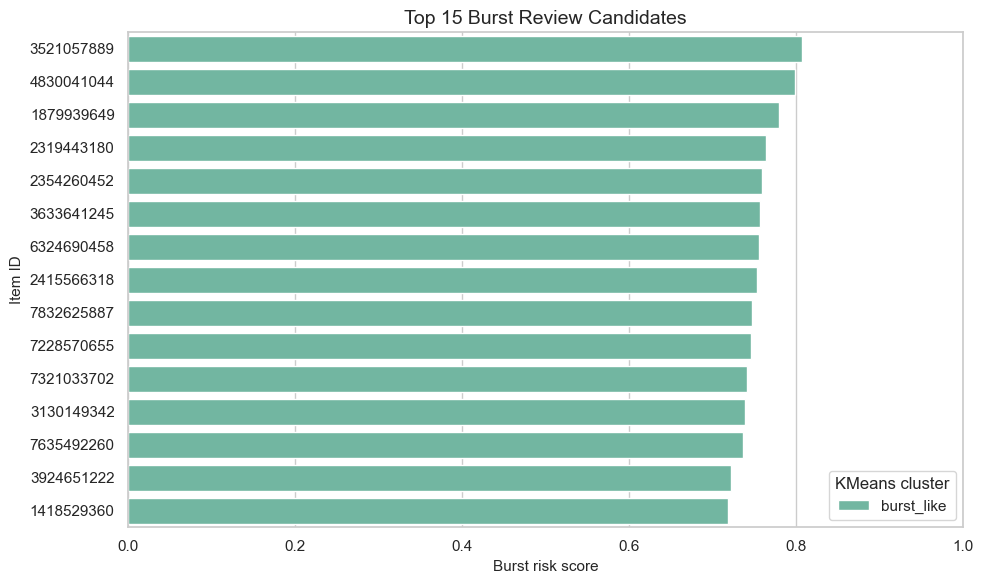

,item_id,review_count,max_reviews_per_window,span_days,unique_users,burst_risk_score,dbscan_cluster,is_dbscan_anomaly,kmeans_cluster_name
0,3521057889,50,12,23.149711,32,0.8068,-1,True,burst_like
1,4830041044,50,9,22.731250,34,0.7987,-1,True,burst_like
2,1879939649,50,22,30.565961,27,0.7788,-1,True,burst_like
3,2319443180,50,8,30.907535,30,0.7639,-1,True,burst_like
4,2354260452,50,8,25.900845,32,0.7595,-1,True,burst_like
5,3633641245,50,23,12.524595,50,0.7569,-1,True,burst_like
6,6324690458,50,19,27.512639,45,0.7555,-1,True,burst_like
7,2415566318,50,13,11.312685,49,0.7533,-1,True,burst_like
8,7832625887,50,8,22.911308,50,0.7467,0,False,burst_like
9,7228570655,50,8,34.499861,20,0.7459,-1,True,burst_like


In [9]:
top_candidates = cluster_df.nlargest(15, "burst_risk_score").copy()
top_candidates["item_label"] = top_candidates["item_id"].astype(str)

ax = sns.barplot(
    data=top_candidates,
    y="item_label",
    x="burst_risk_score",
    hue="kmeans_cluster_name",
    dodge=False,
    palette="Set2",
)
ax.set_title("Top 15 Burst Review Candidates")
ax.set_xlabel("Burst risk score")
ax.set_ylabel("Item ID")
ax.set_xlim(0, max(1.0, top_candidates["burst_risk_score"].max() * 1.05))
sns.move_legend(ax, "lower right", title="KMeans cluster")
plt.tight_layout()
plt.show()

top_candidates[
    [
        "item_id",
        "review_count",
        "max_reviews_per_window",
        "span_days",
        "unique_users",
        "burst_risk_score",
        "dbscan_cluster",
        "is_dbscan_anomaly",
        "kmeans_cluster_name",
    ]
].reset_index(drop=True)